In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
train_path = "Dataset/UNSW_NB15_training-set.csv"
test_path = "Dataset/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset loaded successfully")
print("Testing dataset loaded successfully")

Training dataset loaded successfully
Testing dataset loaded successfully


In [4]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (175341, 45)
Testing Dataset Shape: (82332, 45)


In [5]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [6]:
print("Columns in the dataset:\n")

for i, column in enumerate(train_df.columns, start=1):
    print(i, "→", column)

Columns in the dataset:

1 → id
2 → dur
3 → proto
4 → service
5 → state
6 → spkts
7 → dpkts
8 → sbytes
9 → dbytes
10 → rate
11 → sttl
12 → dttl
13 → sload
14 → dload
15 → sloss
16 → dloss
17 → sinpkt
18 → dinpkt
19 → sjit
20 → djit
21 → swin
22 → stcpb
23 → dtcpb
24 → dwin
25 → tcprtt
26 → synack
27 → ackdat
28 → smean
29 → dmean
30 → trans_depth
31 → response_body_len
32 → ct_srv_src
33 → ct_state_ttl
34 → ct_dst_ltm
35 → ct_src_dport_ltm
36 → ct_dst_sport_ltm
37 → ct_dst_src_ltm
38 → is_ftp_login
39 → ct_ftp_cmd
40 → ct_flw_http_mthd
41 → ct_src_ltm
42 → ct_srv_dst
43 → is_sm_ips_ports
44 → attack_cat
45 → label


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [8]:
missing_values = train_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
print("Number of duplicate rows:", train_df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
train_df['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

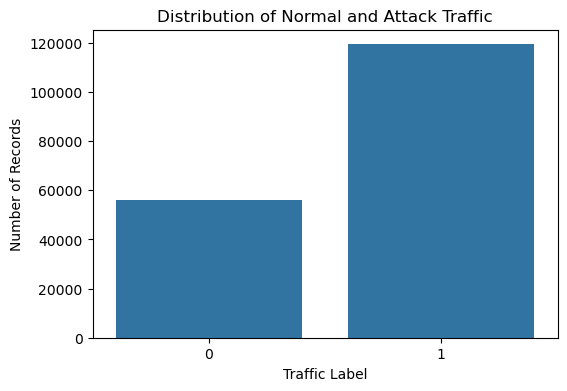

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=train_df, x='label')

plt.title("Distribution of Normal and Attack Traffic")
plt.xlabel("Traffic Label")
plt.ylabel("Number of Records")

plt.show()

In [12]:
train_df['attack_cat'].value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

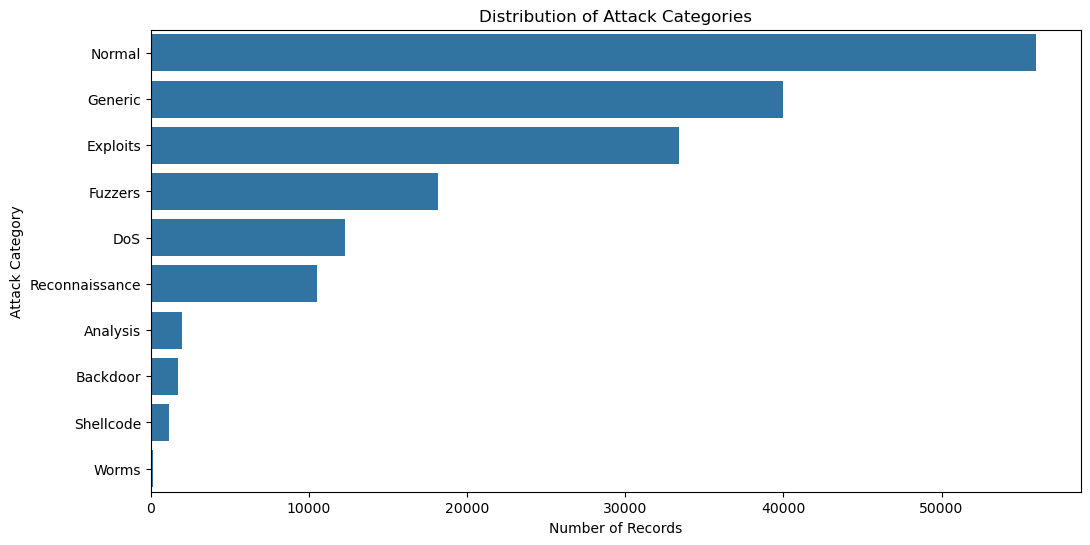

In [13]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=train_df,
    y='attack_cat',
    order=train_df['attack_cat'].value_counts().index
)

plt.title("Distribution of Attack Categories")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")

plt.show()

In [14]:
pd.set_option('display.max_rows', 100)

column_info = pd.DataFrame({
    'Column': train_df.columns,
    'Data_Type': train_df.dtypes.values,
    'Unique_Values': train_df.nunique().values,
    'Missing_Values': train_df.isnull().sum().values
})

column_info

,Column,Data_Type,Unique_Values,Missing_Values
0,id,int64,175341,0
1,dur,float64,74039,0
2,proto,object,133,0
3,service,object,13,0
4,state,object,9,0
5,spkts,int64,480,0
6,dpkts,int64,443,0
7,sbytes,int64,7214,0
8,dbytes,int64,6660,0
9,rate,float64,76991,0


In [15]:
train_df.head().T

,0,1,2,3,4
id,1,2,3,4,5
dur,0.121478,0.649902,1.623129,1.681642,0.449454
proto,tcp,tcp,tcp,tcp,tcp
service,-,-,-,ftp,-
state,FIN,FIN,FIN,FIN,FIN
spkts,6,14,8,12,10
dpkts,4,38,16,12,6
sbytes,258,734,364,628,534
dbytes,172,42014,13186,770,268
rate,74.08749,78.473372,14.170161,13.677108,33.373826


In [16]:
print("Label values:")
print(train_df['label'].value_counts())

print("\nAttack categories:")
print(train_df['attack_cat'].value_counts())

Label values:
label
1    119341
0     56000
Name: count, dtype: int64

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [17]:
train_df = train_df.drop(columns=['id'])
test_df = test_df.drop(columns=['id'])

In [18]:
print(train_df.shape)
print(test_df.shape)

(175341, 44)
(82332, 44)


In [19]:
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,3,1,1,0,2,1,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,1,40,0,0,0,2,39,0,Normal,0


In [20]:
categorical_columns = train_df.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = train_df.select_dtypes(
    exclude=['object']
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['proto', 'service', 'state', 'attack_cat']

Numerical Columns:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']


In [21]:
X_train = train_df.drop(columns=['label', 'attack_cat'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label', 'attack_cat'])
y_test = test_df['label']

In [22]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (175341, 42)
y_train shape: (175341,)
X_test shape: (82332, 42)
y_test shape: (82332,)


In [23]:
categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:",
      len(categorical_features))

print("\nNumber of Numerical Features:",
      len(numerical_features))

Categorical Features:
['proto', 'service', 'state']

Number of Categorical Features: 3

Number of Numerical Features: 39


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [28]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (175341, 194)
Processed X_test shape: (82332, 194)


In [29]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [30]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [31]:
y_pred_lr = logistic_model.predict(X_test_processed)

y_prob_lr = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [32]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(y_test, y_pred_lr)

recall_lr = recall_score(y_test, y_pred_lr)

f1_lr = f1_score(y_test, y_pred_lr)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-Score :", f1_lr)
print("ROC-AUC  :", roc_auc_lr)

Logistic Regression Results
-----------------------------------
Accuracy : 0.8097459068163048
Precision: 0.7535466447885687
Recall   : 0.97253595693991
F1-Score : 0.8491496369344556
ROC-AUC  : 0.9557820136601791


In [33]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Normal', 'Attack']
    )
)

              precision    recall  f1-score   support

      Normal       0.95      0.61      0.74     37000
      Attack       0.75      0.97      0.85     45332

    accuracy                           0.81     82332
   macro avg       0.85      0.79      0.80     82332
weighted avg       0.84      0.81      0.80     82332



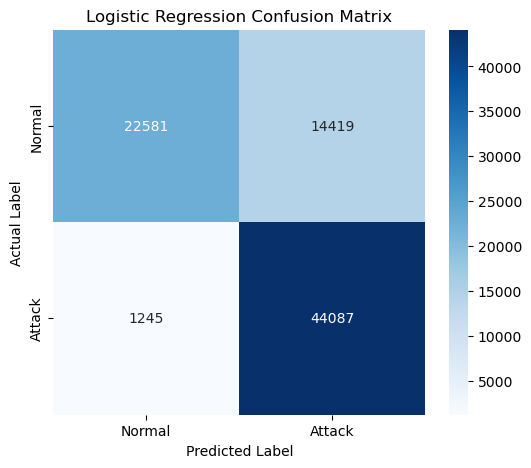

In [34]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [37]:
y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [38]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 30)
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

Random Forest Results
------------------------------
Accuracy : 0.8714473108876257
Precision: 0.8173913043478261
Recall   : 0.9870290302655961
F1-Score : 0.8942361499720202
ROC-AUC  : 0.9790591050770174


In [39]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Normal', 'Attack']
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.73      0.84     37000
      Attack       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332



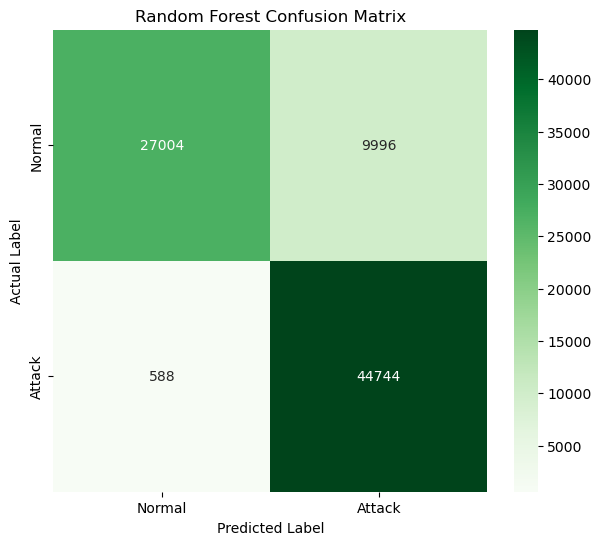

In [40]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [41]:
feature_importance = rf_model.feature_importances_

print("Number of feature importance values:",
      len(feature_importance))

Number of feature importance values: 194


In [42]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
6,num__sttl,0.092572
28,num__ct_state_ttl,0.071912
5,num__rate,0.059182
9,num__dload,0.053701
8,num__sload,0.046759
37,num__ct_srv_dst,0.039150
3,num__sbytes,0.038996
20,num__tcprtt,0.037687
2,num__dpkts,0.032096
32,num__ct_dst_src_ltm,0.031701


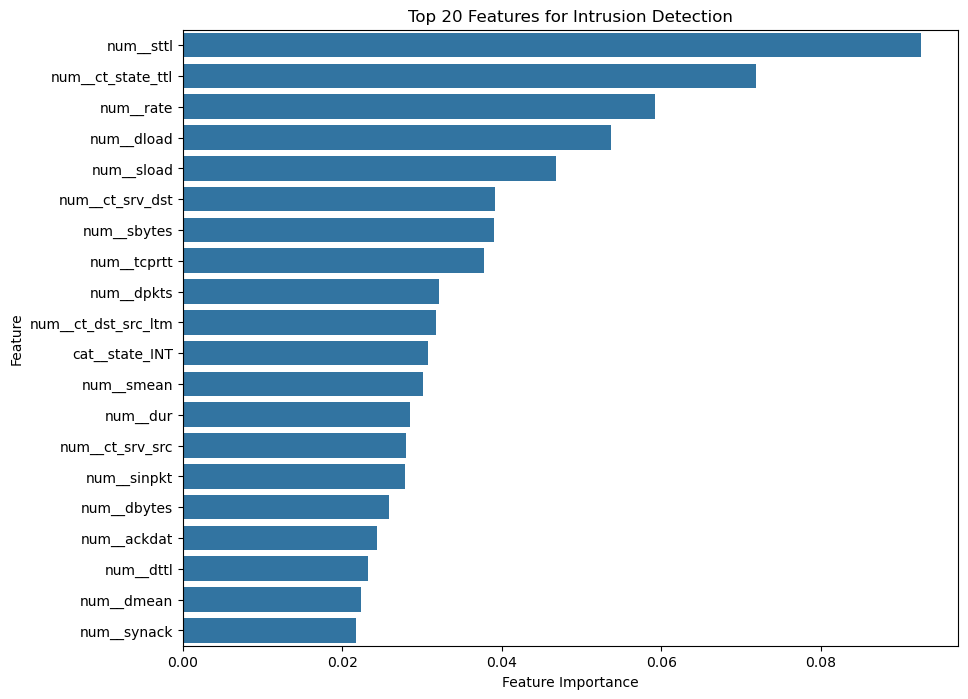

In [43]:
plt.figure(figsize=(10, 8))

top_features = importance_df.head(20)

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Features for Intrusion Detection")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [44]:
import xgboost as xgb

print(xgb.__version__)

3.0.4


In [45]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [46]:
y_pred_xgb = xgb_model.predict(X_test_processed)

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [47]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("-" * 30)
print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1-Score :", f1_xgb)
print("ROC-AUC  :", roc_auc_xgb)

XGBoost Results
------------------------------
Accuracy : 0.8737428946217752
Precision: 0.8207760251207374
Recall   : 0.9859922350657372
F1-Score : 0.8958302017256411
ROC-AUC  : 0.9842860576980403


In [48]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_rf,
        accuracy_xgb
    ],
    'Precision': [
        precision_lr,
        precision_rf,
        precision_xgb
    ],
    'Recall': [
        recall_lr,
        recall_rf,
        recall_xgb
    ],
    'F1-Score': [
        f1_lr,
        f1_rf,
        f1_xgb
    ],
    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.809746,0.753547,0.972536,0.849150,0.955782
1,Random Forest,0.871447,0.817391,0.987029,0.894236,0.979059
2,XGBoost,0.873743,0.820776,0.985992,0.895830,0.984286


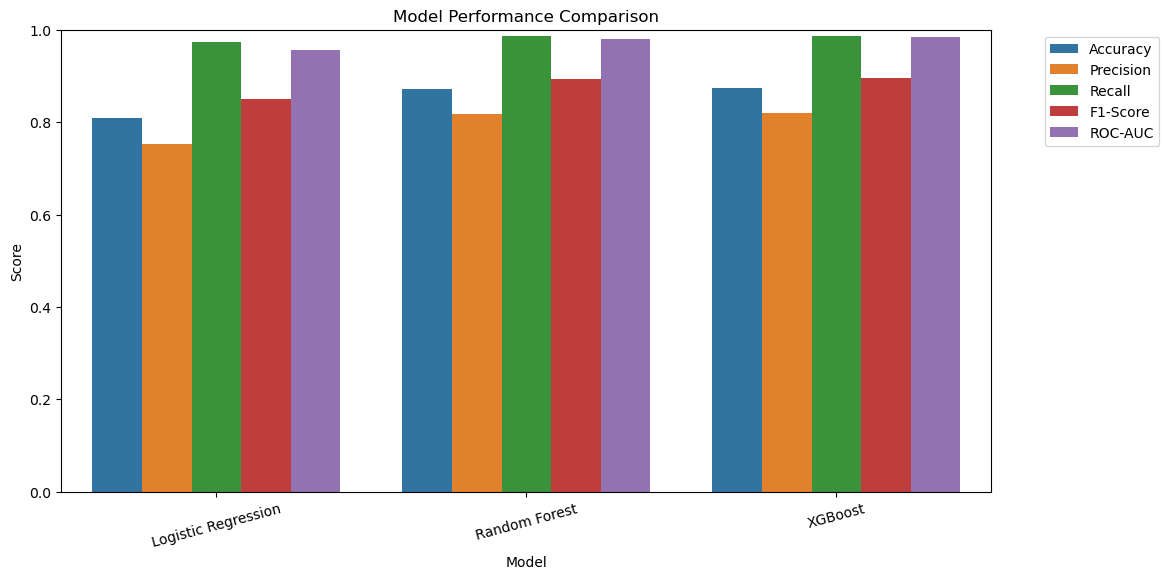

In [49]:
plt.figure(figsize=(12, 6))

results_melted = results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

sns.barplot(
    data=results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

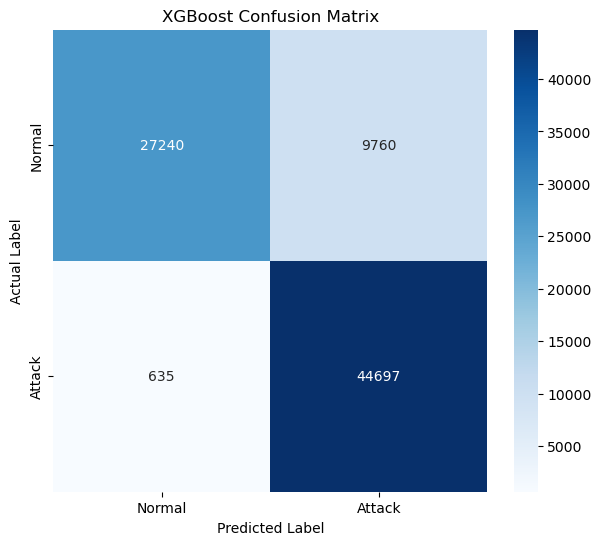

In [50]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [51]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=['Normal', 'Attack']
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.74      0.84     37000
      Attack       0.82      0.99      0.90     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332



In [52]:
xgb_importance = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
})

xgb_importance_df = xgb_importance_df.sort_values(
    by='Importance',
    ascending=False
)

xgb_importance_df.head(20)

,Feature,Importance
6,num__sttl,0.613913
37,num__ct_srv_dst,0.035015
28,num__ct_state_ttl,0.025813
3,num__sbytes,0.022458
31,num__ct_dst_sport_ltm,0.022247
7,num__dttl,0.017933
185,cat__state_CON,0.017776
23,num__smean,0.012394
9,num__dload,0.011947
10,num__sloss,0.011640


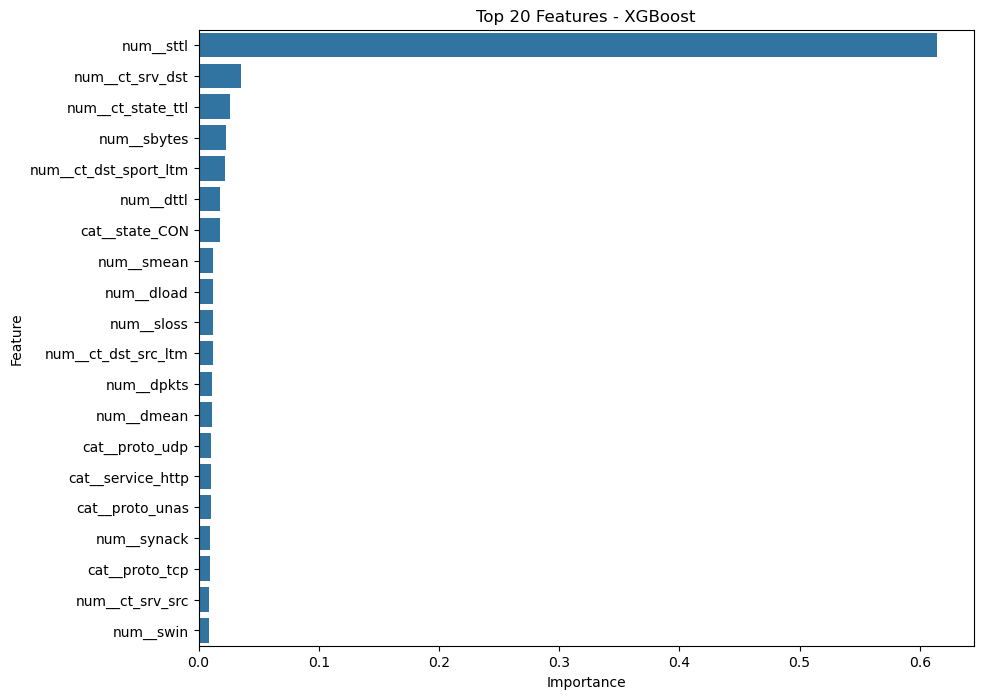

In [53]:
plt.figure(figsize=(10, 8))

top_xgb_features = xgb_importance_df.head(20)

sns.barplot(
    data=top_xgb_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

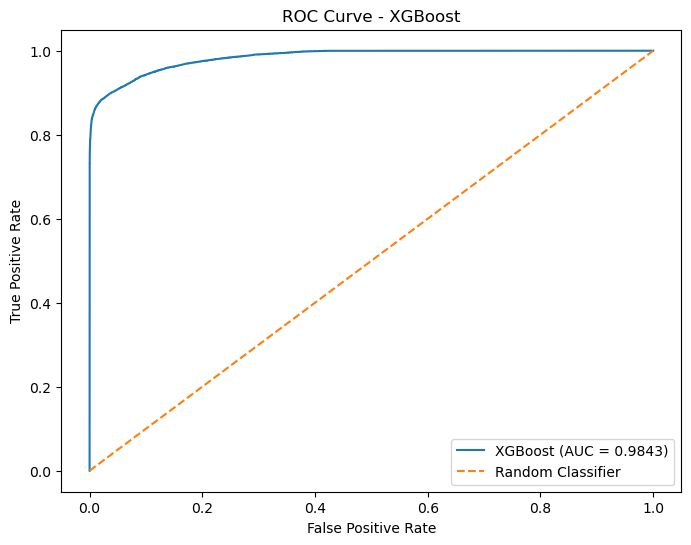

In [54]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC = {roc_auc_xgb:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

In [55]:
final_metrics = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        roc_auc_xgb
    ]
})

final_metrics

,Metric,Score
0,Accuracy,0.873743
1,Precision,0.820776
2,Recall,0.985992
3,F1-Score,0.895830
4,ROC-AUC,0.984286


In [56]:
xgb_importance_df.head(20)

,Feature,Importance
6,num__sttl,0.613913
37,num__ct_srv_dst,0.035015
28,num__ct_state_ttl,0.025813
3,num__sbytes,0.022458
31,num__ct_dst_sport_ltm,0.022247
7,num__dttl,0.017933
185,cat__state_CON,0.017776
23,num__smean,0.012394
9,num__dload,0.011947
10,num__sloss,0.011640


In [59]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    xgb_model,
    "models/xgboost_intrusion_model.pkl"
)

joblib.dump(
    preprocessor,
    "models/preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
